# Rota da Neuromante - MLP com otimização

###### Notebook produzido por Ana Carolina Sayumi Imahata Alves

O principal objetivo deste notebook é desenvolver a otimização de uma rede neural do tipo MLP Classificadora Binária. Para mais detalhes sobre a rede neural, não sua otimização, cheque o notebook `Rota da Neuromante - MLP sem otimização`.

## Imports e tratamento de dados

Os imports são similares àqueles feitos para a MLP sem otimização, apenas adicionamos os necessários para realizar a otimização por `optuna`.

In [ ]:
import lightning as L
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import random
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from optuna import create_study
import optuna


import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as savefig

In [13]:
SEED = 43

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
L.seed_everything(SEED, workers=True)

Seed set to 43


43

In [18]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        tamanho_teste=0.2,
        tamanho_val=0.1,
        tamanho_lote=32,
        num_trabalhadores=0,
        semente_aleatoria=43,
    ):
        super().__init__()

        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores
        self.tamanho_teste = tamanho_teste
        self.tamanho_val = tamanho_val
        self.semente_aleatoria = semente_aleatoria

    def prepare_data(self):
        pd.read_excel("Dataset_Alzheimers_sep.xlsx")

    def setup(self, stage):
        """Ocorre após o `prepare_data`. Aqui devemos alterar o estado da classe
        para adicionar as informações referentes aos conjuntos de treino, teste
        e validação. O argumento `stage` deve existir e ele indica em qual
        estágio o processo de treino está (pode ser `fit` para
        treinamento/validação e `test` para teste).

        É nesta etapa onde aplicamos transformações aos dados caso necessário.
        """

        df = pd.read_excel("Dataset_Alzheimers_sep.xlsx")

        df = df.reset_index(drop=True)

        # Passando o encoder
        le = LabelEncoder()
        df["Class"] = le.fit_transform(df["Class"])

        encoder = OneHotEncoder(sparse_output=False)
        genotype_encoded = encoder.fit_transform(df[["Genotype"]])
        genotype_cols = encoder.get_feature_names_out(["Genotype"])

        df = df.drop(columns=["Genotype"])
        df = pd.concat([df, pd.DataFrame(genotype_encoded, columns=genotype_cols, index=df.index)], axis=1)

        # Armazenando atributos e target
        ATRIBUTOS = df.columns.tolist()
        ATRIBUTOS.remove('Class')
        TARGET = ["Class"]

        # Atualizando o df e removendo dados ausentes
        df = df.reindex(ATRIBUTOS + TARGET, axis=1)

        df_target = df[TARGET]

        indices = df.index
        indices_treino_val, indices_teste = train_test_split(
            indices,
            test_size=self.tamanho_teste,
            random_state=self.semente_aleatoria,
            stratify=df_target
        )

        df_treino_val = df.loc[indices_treino_val]
        df_teste = df.loc[indices_teste]

        indices = df_treino_val.index
        indices_treino, indices_val = train_test_split(
            indices,
            test_size=self.tamanho_val,
            random_state=self.semente_aleatoria,
            stratify=df_treino_val[TARGET] 
        )

        df_treino = df.loc[indices_treino]
        df_val = df.loc[indices_val]

        X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
        y_treino = df_treino.reindex(TARGET, axis=1).values

        self.x_scaler = MaxAbsScaler()
        self.x_scaler.fit(X_treino)

        if stage == "fit":
            X_val = df_val.reindex(ATRIBUTOS, axis=1).values
            y_val = df_val.reindex(TARGET, axis=1).values

            X_treino = self.x_scaler.transform(X_treino)
            X_val = self.x_scaler.transform(X_val)

            self.X_treino = torch.tensor(X_treino, dtype=torch.float32)
            self.X_val = torch.tensor(X_val, dtype=torch.float32)
    
            self.y_treino = torch.tensor(y_treino, dtype=torch.long).squeeze(1)
            self.y_val   = torch.tensor(y_val,   dtype=torch.long).squeeze(1)

        if stage == "test":
            X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
            y_teste = df_teste.reindex(TARGET, axis=1).values

            X_teste = self.x_scaler.transform(X_teste)

            self.X_teste = torch.tensor(X_teste, dtype=torch.float32)
            self.y_teste = torch.tensor(y_teste, dtype=torch.long).squeeze(1)

    def train_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_treino, self.y_treino),
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            shuffle=True,
        )

    def val_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_val, self.y_val),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

    def test_dataloader(self):
        return DataLoader(
            TensorDataset(self.X_teste, self.y_teste),
            batch_size=self.tamanho_lote * 2,
            num_workers=self.num_trabalhadores,
            shuffle=False,
        )

## Construindo a MLP com otimização por `optuna`

Neste notebook iremos explorar a otimização dos seguintes hiperparâmetros:

-   Número de camadas ocultas. Para dados tabulados eu costumo utilizar de 1 a 3 camadas. 
-   Número de neurônios em cada camada oculta. Cada camada pode ter um número diferente de neurônios.
-   Função de ativação. É comum utilizar a mesma função de ativação na rede neural inteira, porém é possível que cada camada tenha uma função de ativação diferente. Um excelente primeiro teste é utilizando ReLU como função de ativação para as camadas ocultas.

E o que mudar para a otimização?

O que precisaremos mudar em nossa estrutura para poder fazer a otimização com o optuna é a construção do `self.camadas`, ou seja, o que será recebido no `nn.Sequential`. Como uma MLP é definida, principalmente, por número de camadas, neurônios por camada e função de ativação, é preciso construir nossa classe de modo a sortear valores para cada um desses hiperparâmetros, sendo possível passá-los depois para o Sequential.

O sorteio de valores pelo optuna já nos é familiar, usando a função `trial.suggest`.

Começando pelo número de camadas, como não temos um número fixo, para cada sugestão obtida é necessário um loop que receba esse número de camadas. Nesse loop, sabemos que serão sorteados $n$ neurônios por camada, então é preciso que este trial esteja incluso ali. Mas, uma vez com o número de neurônios de uma camada $n$, é preciso informar a camada seguinte $n+1$ o número que será recebido, então atualizamos dentro do loop qual a entrada. Além disso, precisamos da função de ativação de cada camada, sugerida pelo `trial`. Assim, basta apenas armazenar essas diferentes camadas de modo a desempacotar no nosso `Sequential` e passar a camada de saída - porque sua função de ativação não pode ser randomizada.

Assim, mudamos também os argumentos para instanciar a classe (que agora serão: número de dados de entrada, número de targets e trial do optuna).

In [48]:
class MLP_otim(L.LightningModule):
    def __init__(self, num_dados_entrada, num_targets, trial):
        super().__init__()

        #vai armazenar os dados das camadas
        layers = []

        #para não ter problema atualizando o argumento
        n_entrada = num_dados_entrada

        #sugere o número de camadas
        n_layers = trial.suggest_int("n_layers", 2, 8)

        #loop para atribuir hiperparâmetros a cada camada
        for i in range(n_layers):
            #sugere o número de neurônios - n dados de saida
            n_saida = trial.suggest_int(f"n_neuronios{i}", 4, 30)

            #acrescenta nas camadas a entrada e saída
            layers.append(nn.Linear(n_entrada, n_saida))

            #sorteia a função de ativação a ser acrescentada em seguida
            func_ativação = trial.suggest_categorical(f"f_ativação{i}", ["relu", "gelu"])

            if func_ativação == "relu":
                layers.append(nn.ReLU())
            else:
                layers.append(nn.GELU())

            #atualiza o número de entrada para o número de neuronios sorteados
            #ou seja, a saida da camada passada
            n_entrada = n_saida

        #adiciona a última camada da MLP - pronta para passar na função de perda
        layers.append(nn.Linear(n_entrada, num_targets))

        #operador estrela para desempacotar a lista
        self.camadas = nn.Sequential(*layers)

        #função de perda adequada para classificação
        self.fun_perda = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.7], dtype=torch.float32))

        self.perdas_treino = []
        self.perdas_val = []

        self.curva_aprendizado_treino = []
        self.curva_aprendizado_val = []

    def forward(self, x):
        x = self.camadas(x)
        return x

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("loss", loss, prog_bar=True)
        self.perdas_treino.append(loss)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("val_loss", loss, prog_bar=True)
        self.perdas_val.append(loss)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.fun_perda(y_pred, y)

        self.log("test_loss", loss)

        return loss

    def on_train_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_treino).mean()
        self.curva_aprendizado_treino.append(float(perda_media))
        self.perdas_treino.clear()

    def on_validation_epoch_end(self):
        # Atualiza curva de aprendizado
        perda_media = torch.stack(self.perdas_val).mean()
        self.curva_aprendizado_val.append(float(perda_media))
        self.perdas_val.clear()

Como nossa função objetivo tem apenas o trial como argumento, basta criar o estudo e rodar, sem a necessidade um uma função parcial.

In [39]:
MAX_EPOCAS = 200

def funçao_objetivo_MLP(trial):
    dm = DataModule()
    dm.setup("fit")
    
    modelo = MLP_otim(num_dados_entrada=136, num_targets=2, trial=trial)

    treinador = L.Trainer(max_epochs=MAX_EPOCAS)
    treinador.fit(modelo, dm)

    val_perda = treinador.callback_metrics["val_loss"].item()

    return treinador.callback_metrics["val_loss"].item()

Aqui criamos um estudo para a otimização.

In [40]:
NOME_DO_ESTUDO = "MLP_otim"

objeto_de_estudo_MLP = create_study(
    direction="minimize",
    study_name=NOME_DO_ESTUDO,
    storage=f"sqlite:///{NOME_DO_ESTUDO}.db",
    load_if_exists=True,)

[I 2026-06-07 19:21:15,796] Using an existing study with name 'MLP_otim' instead of creating a new one.


E rodamos o optuna.

In [41]:
N_TENTATIVAS = 100

objeto_de_estudo_MLP.optimize(funçao_objetivo_MLP, n_trials=N_TENTATIVAS, n_jobs=4)

melhor_trial_MLP = objeto_de_estudo_MLP.best_trial
print(f"""O melhor trial foi o {melhor_trial_MLP.number} 
com os seguintes parâmetros: {melhor_trial_MLP.params}""")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloade

Training: |          | 0/? [00:00<?, ?it/s]


  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 2.4 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
2.4 K     Trainable params
0         Non-trainable params
2.4 K     Total params
0.010     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
0         Total Flops


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.
[I 2026-06-07 20:31:34,894] Trial 123 finished with value: 0.6859593987464905 and parameters: {'n_layers': 2, 'n_neuronios0': 16, 'f_ativação0': 'relu', 'n_neuronios1': 4, 'f_ativação1': 'relu'}. Best is trial 122 with value: 0.6121193170547485.


O melhor trial foi o 122 
com os seguintes parâmetros: {'n_layers': 2, 'n_neuronios0': 20, 'f_ativação0': 'relu', 'n_neuronios1': 4, 'f_ativação1': 'relu'}


Agora iremos obter os melhores parâmetros descobertos com o `optuna`.

In [42]:
melhores_params_MLP = melhor_trial_MLP.params

melhor_trial_formato_trial = optuna.trial.FixedTrial(melhores_params_MLP)

Note que alteramos o formato do melhor_trial para `trial`, uma vez que esse é o tipo de objeto que nossa rede recebe como argumento.

Uma vez com os melhores parâmetros, podemos finalmente treinar nosso modelo.

In [55]:
dm = DataModule()

modelo_otimizado = MLP_otim(
    num_dados_entrada=136,
    num_targets=2,
    trial=melhor_trial_formato_trial
)

treinador = L.Trainer(max_epochs=50)

treinador.fit(modelo_otimizado, dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | camadas   | Sequential       | 2.8 K  | train | 0    
1 | fun_perda | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\ana25003\AppData\Roaming\Python\Python312\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of tra

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


O número de épocas aqui foi definido com base na convergência. A partir de aproximadamente 50 épocas o modelo passava a errar por overfitting, subindo o erro para o conjunto de validação.

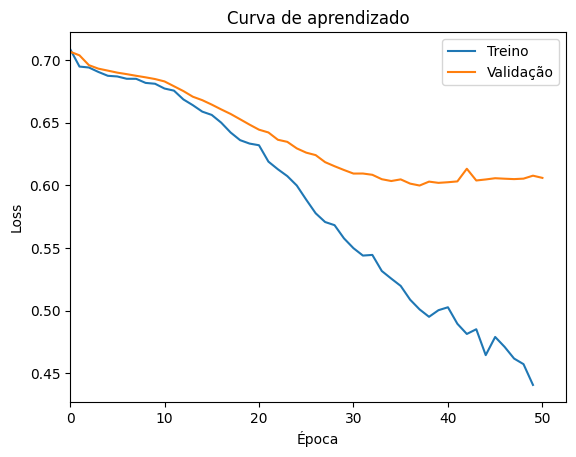

In [56]:
ca_treino = modelo_otimizado.curva_aprendizado_treino
ca_val = modelo_otimizado.curva_aprendizado_val

sns.lineplot(ca_treino, label="Treino")
eixo = sns.lineplot(ca_val, label="Validação")

eixo.set_xlim(left=0)
eixo.set(title="Curva de aprendizado", xlabel="Época", ylabel="Loss");

Feito isso, basta alterar o estado da classe e verificar seu desempenho.

In [57]:
modelo_otimizado.eval()
dm.setup("test")

Aqui iremos utilizar a F1-score e a metriz de confusão.

              precision    recall  f1-score   support

     Control       0.90      0.76      0.82        49
    Impaired       0.54      0.78      0.64        18

    accuracy                           0.76        67
   macro avg       0.72      0.77      0.73        67
weighted avg       0.80      0.76      0.77        67



<Axes: >

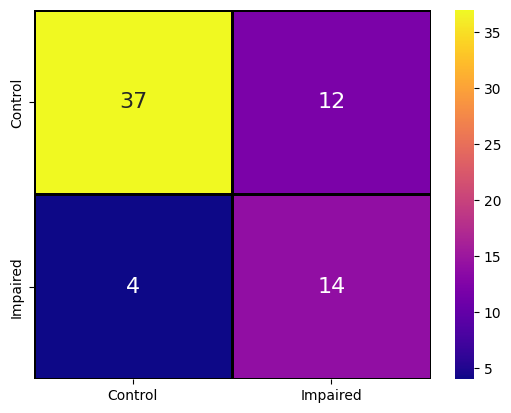

In [ ]:
with torch.no_grad():
    y_pred_classes = modelo_otimizado(dm.X_teste).argmax(dim=1).numpy()
    y_true = dm.y_teste.numpy()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=["Control", "Impaired"]))

# Confusion matrix
labels = ["Control", "Impaired"]
matriz_conf = confusion_matrix(y_true, y_pred_classes)
df_conf = pd.DataFrame(matriz_conf, labels, labels)

sns.heatmap(df_conf, cmap="plasma", annot=True, annot_kws={"size": 16}, linewidths=1, linecolor='black')

savefig("ConfMat_MLP_otim.png")

## Resultados e conclusão

Podemos observar que o modelo teve um desempenho razoável. Embora não tenham havido apenas acertos, podemos notar que, para a classe minoritária (e a mais relevante em nosso caso), houve um desempenho bom, com taxa de acerto de 77%. Seu F1-score médio foi de 0.73.

Para análise comparativa dos resultados, retorne ao notebook `0 - A Rota da Neuromante - Análise do problema, discussão de resultados e conclusão`.